# Steam Dataset Exploration for LLM-Rec

## Objectives

1. Understand the structure and scale of the Steam dataset
2. Check ID alignment between `steam_games.json` and `steam_new.json`
3. Analyze sequence length distribution (→ RecCL feasibility)
4. Analyze item popularity distribution (→ SANS tail-item opportunity)
5. Analyze genre/tag diversity (→ RecAug semantic augmentation)
6. Temporal patterns (→ session boundary detection)
7. Text quality assessment (→ LLM-based operations)

In [15]:
import ast
import json
import sys
import os
from collections import Counter, defaultdict
from datetime import datetime
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sys.path.insert(0, os.path.dirname(os.getcwd()))
from utils.steam_utils import parse_steam_line, parse_steam_file, build_item_text, normalize_genres

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

DATA_DIR = '../data'

## 1. Load and Parse Data

In [16]:
# Load game catalog
print('Loading steam_games.json ...')
games = parse_steam_file(os.path.join(DATA_DIR, 'steam_games.json'))
print(f'Loaded {len(games):,} games')

# Sample record
games[0]

Loading steam_games.json ...
Loaded 32,135 games


{'publisher': 'Kotoshiro',
 'genres': ['Action', 'Casual', 'Indie', 'Simulation', 'Strategy'],
 'app_name': 'Lost Summoner Kitty',
 'title': 'Lost Summoner Kitty',
 'url': 'http://store.steampowered.com/app/761140/Lost_Summoner_Kitty/',
 'release_date': '2018-01-04',
 'tags': ['Strategy', 'Action', 'Indie', 'Casual', 'Simulation'],
 'discount_price': 4.49,
 'reviews_url': 'http://steamcommunity.com/app/761140/reviews/?browsefilter=mostrecent&p=1',
 'specs': ['Single-player'],
 'price': 4.99,
 'early_access': False,
 'id': '761140',
 'developer': 'Kotoshiro'}

In [17]:
# Load user reviews/play records (sample first for speed; remove max_lines for full)
print('Loading steam_new.json ...')
MAX_REVIEWS = 500000  # Adjust: None for all 7.8M records
reviews = parse_steam_file(os.path.join(DATA_DIR, 'steam_new.json'), max_lines=MAX_REVIEWS)
print(f'Loaded {len(reviews):,} reviews (sampled)')

# Sample record
reviews[0]

Loading steam_new.json ...
Loaded 500,000 reviews (sampled)


{'username': 'Chaos Syren',
 'hours': 0.1,
 'products': 41,
 'product_id': '725280',
 'page_order': 0,
 'date': '2017-12-17',
 'text': 'This would not be acceptable as an entertainment even back in the day when these graphics were all there was to be had. No effort has been made to bring the player into any story or even entertain.',
 'early_access': False,
 'page': 1}

## 2. Game Catalog Analysis

In [18]:
# Field coverage
field_coverage = {}
for g in games:
    for key in g:
        field_coverage[key] = field_coverage.get(key, 0) + 1

print('Field coverage in steam_games.json:')
for k, v in sorted(field_coverage.items()):
    print(f'  {k:20s}: {v:6d}/{len(games)} ({v/len(games)*100:.1f}%)')

# Check unique IDs
game_ids = set()
for g in games:
    if 'id' in g:
        game_ids.add(str(g['id']))
print(f'\nUnique game IDs: {len(game_ids):,}')
print(f'Total games:     {len(games):,}')
print(f'ID uniqueness:   {len(game_ids)/len(games)*100:.1f}%')

Field coverage in steam_games.json:
  app_name            :  32133/32135 (100.0%)
  developer           :  28836/32135 (89.7%)
  discount_price      :    225/32135 (0.7%)
  early_access        :  32135/32135 (100.0%)
  genres              :  28852/32135 (89.8%)
  id                  :  32133/32135 (100.0%)
  metascore           :   2677/32135 (8.3%)
  price               :  30758/32135 (95.7%)
  publisher           :  24083/32135 (74.9%)
  release_date        :  30068/32135 (93.6%)
  reviews_url         :  32133/32135 (100.0%)
  sentiment           :  24953/32135 (77.7%)
  specs               :  31465/32135 (97.9%)
  tags                :  31972/32135 (99.5%)
  title               :  30085/32135 (93.6%)
  url                 :  32135/32135 (100.0%)

Unique game IDs: 32,132
Total games:     32,135
ID uniqueness:   100.0%


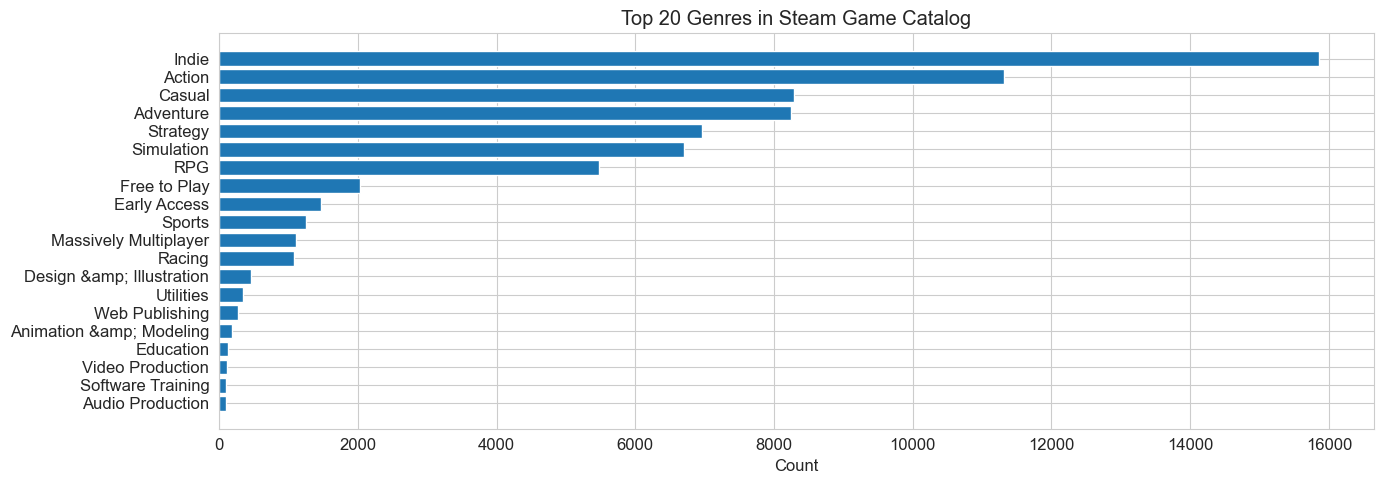

Total unique genres: 22
Avg genres per game: 2.2


In [19]:
# Genre distribution
all_genres = []
for g in games:
    if 'genres' in g:
        all_genres.extend(g['genres'])
genre_counts = Counter(all_genres)

fig, ax = plt.subplots(figsize=(14, 5))
top_genres = genre_counts.most_common(20)
ax.barh([g[0] for g in top_genres], [g[1] for g in top_genres])
ax.set_xlabel('Count')
ax.set_title('Top 20 Genres in Steam Game Catalog')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'Total unique genres: {len(genre_counts)}')
print(f'Avg genres per game: {len(all_genres)/len(games):.1f}')

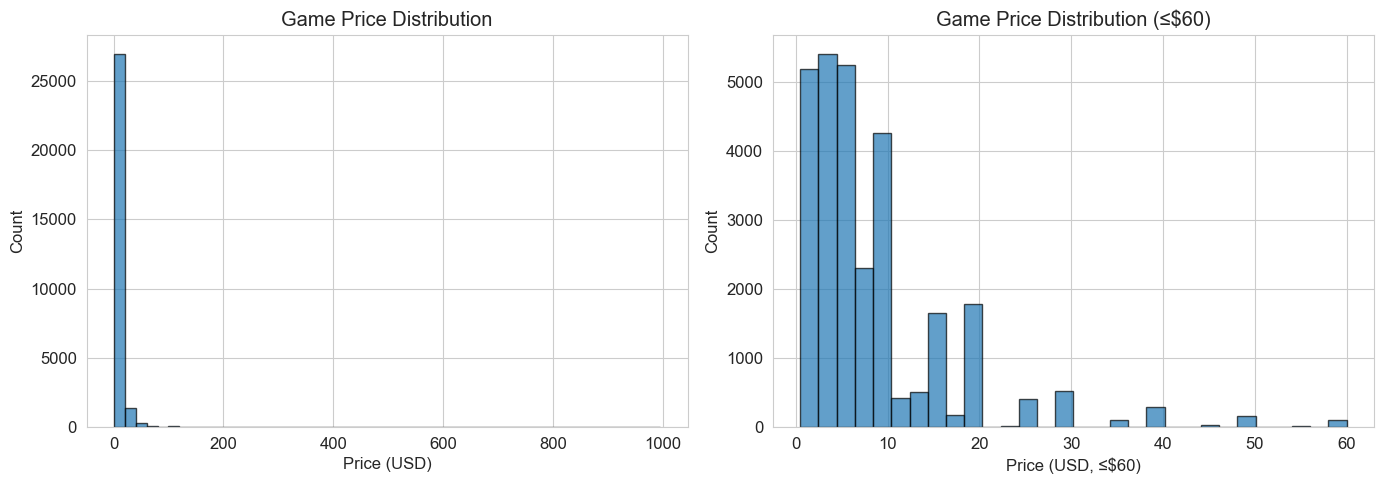

Free games: 0 (0.0%)
Median price: $4.99
Mean price: $9.45


In [20]:
# Price distribution
prices = []
for g in games:
    p = g.get('price')
    if p is not None and isinstance(p, (int, float)):
        prices.append(p)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(prices, bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Price (USD)')
ax1.set_ylabel('Count')
ax1.set_title('Game Price Distribution')

ax2.hist([p for p in prices if p <= 60], bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Price (USD, ≤$60)')
ax2.set_ylabel('Count')
ax2.set_title('Game Price Distribution (≤$60)')
plt.tight_layout()
plt.show()

free_games = sum(1 for p in prices if p == 0)
print(f'Free games: {free_games} ({free_games/len(prices)*100:.1f}%)')
print(f'Median price: ${np.median(prices):.2f}')
print(f'Mean price: ${np.mean(prices):.2f}')

## 3. User Interaction Analysis

In [21]:
# Field coverage in reviews
field_cov = {}
for r in reviews:
    for key in r:
        field_cov[key] = field_cov.get(key, 0) + 1

print('Field coverage in steam_new.json:')
for k, v in sorted(field_cov.items()):
    print(f'  {k:20s}: {v:6d}/{len(reviews)} ({v/len(reviews)*100:.1f}%)')

# Basic stats
users = set()
products = set()
for r in reviews:
    uid = str(r.get('user_id', r.get('username', '')))
    pid = str(r.get('product_id', ''))
    if uid: users.add(uid)
    if pid: products.add(pid)

print(f'\nUnique users (sample):   {len(users):,}')
print(f'Unique products (sample): {len(products):,}')
print(f'Reviews per user:         {len(reviews)/len(users):.1f}')

Field coverage in steam_new.json:
  compensation        :   9619/500000 (1.9%)
  date                : 500000/500000 (100.0%)
  early_access        : 500000/500000 (100.0%)
  found_funny         :  77786/500000 (15.6%)
  hours               : 499523/500000 (99.9%)
  page                : 500000/500000 (100.0%)
  page_order          : 500000/500000 (100.0%)
  product_id          : 500000/500000 (100.0%)
  products            : 499116/500000 (99.8%)
  text                : 500000/500000 (100.0%)
  user_id             : 200484/500000 (40.1%)
  username            : 500000/500000 (100.0%)

Unique users (sample):   366,175
Unique products (sample): 994
Reviews per user:         1.4


In [22]:
# ID alignment: steam_new.product_id ↔ steam_games.id
game_ids = set()
for g in games:
    if 'id' in g:
        game_ids.add(str(g['id']))

review_pids = set()
for r in reviews:
    pid = str(r.get('product_id', ''))
    if pid:
        review_pids.add(pid)

aligned = review_pids & game_ids
review_only = review_pids - game_ids
game_only = game_ids - review_pids

print('=== ID Alignment Check ===')
print(f'Game catalog IDs:     {len(game_ids):,}')
print(f'Review product IDs:   {len(review_pids):,}')
print(f'Aligned (in both):    {len(aligned):,}  ({len(aligned)/max(len(review_pids),1)*100:.1f}%)')
print(f'Review-only (no meta): {len(review_only):,}')
print(f'Game-only (no reviews):{len(game_only):,}')

if review_only:
    print(f'\nSample review-only product IDs: {list(review_only)[:10]}')
if game_only:
    print(f'Sample game-only IDs: {list(game_only)[:10]}')

=== ID Alignment Check ===
Game catalog IDs:     32,132
Review product IDs:   994
Aligned (in both):    994  (100.0%)
Review-only (no meta): 0
Game-only (no reviews):31,138
Sample game-only IDs: ['404530', '345580', '285460', '463360', '446900', '650110', '323490', '392860', '347280', '670410']


## 4. Sequence Length Distribution (→ RecCL)

In [23]:
# Build per-user sequences
user_sequences = defaultdict(list)
for r in reviews:
    uid = str(r.get('user_id', r.get('username', '')))
    pid = str(r.get('product_id', ''))
    if not uid or not pid:
        continue
    if pid in game_ids:  # Only include items with metadata
        user_sequences[uid].append({
            'item_id': pid,
            'hours': float(r.get('hours', 0)),
            'date': r.get('date', ''),
        })

seq_lengths = [len(seq) for seq in user_sequences.values()]
print(f'Users with ≥1 interaction: {len(user_sequences):,}')
print(f'Min seq length:   {min(seq_lengths)}')
print(f'Max seq length:   {max(seq_lengths)}')
print(f'Mean seq length:  {np.mean(seq_lengths):.1f}')
print(f'Median seq length: {np.median(seq_lengths):.1f}')
print(f'Std seq length:   {np.std(seq_lengths):.1f}')

Users with ≥1 interaction: 366,175
Min seq length:   1
Max seq length:   85
Mean seq length:  1.4
Median seq length: 1.0
Std seq length:   1.2


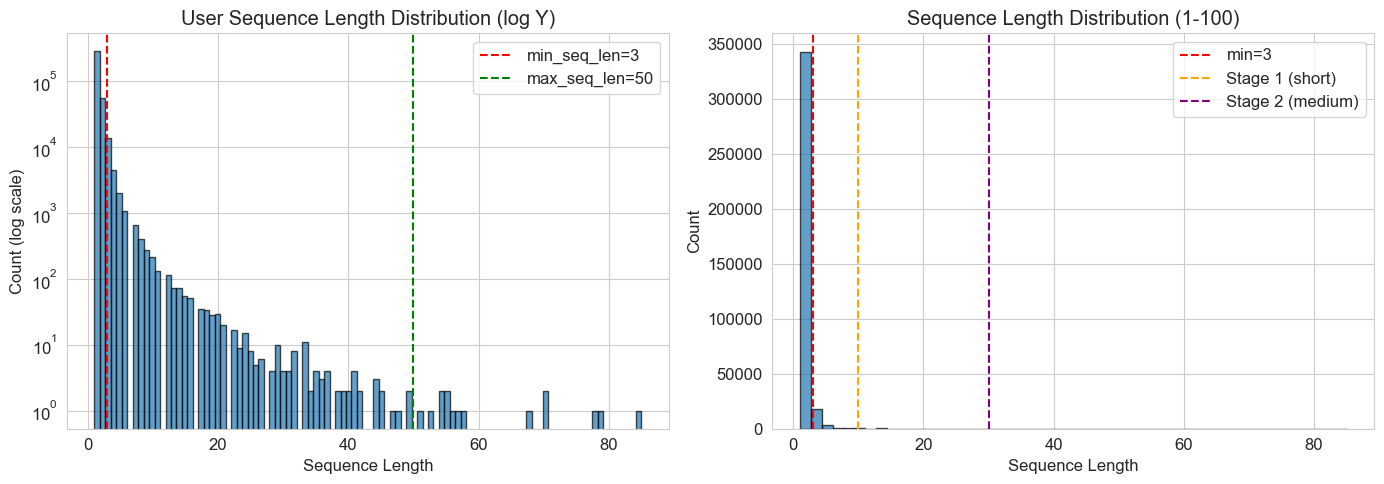


=== RecCL Stage Distribution ===
Stage 1 (short,  ≤10):  99.8% of users
Stage 2 (medium, 11-30): 0.2% of users
Stage 3 (long,   >30):   0.0% of users


In [24]:
# Sequence length histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
ax1.hist(seq_lengths, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.axvline(3, color='red', linestyle='--', label='min_seq_len=3')
ax1.axvline(50, color='green', linestyle='--', label='max_seq_len=50')
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Count (log scale)')
ax1.set_title('User Sequence Length Distribution (log Y)')
ax1.legend()

# Zoomed: 2-100
short = [l for l in seq_lengths if 1 <= l <= 100]
ax2.hist(short, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(3, color='red', linestyle='--', label='min=3')
ax2.axvline(10, color='orange', linestyle='--', label='Stage 1 (short)')
ax2.axvline(30, color='purple', linestyle='--', label='Stage 2 (medium)')
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Count')
ax2.set_title('Sequence Length Distribution (1-100)')
ax2.legend()

plt.tight_layout()
plt.show()

# RecCL curriculum stages
short_pct = sum(1 for l in seq_lengths if l <= 10) / len(seq_lengths) * 100
medium_pct = sum(1 for l in seq_lengths if 10 < l <= 30) / len(seq_lengths) * 100
long_pct = sum(1 for l in seq_lengths if l > 30) / len(seq_lengths) * 100
print(f'\n=== RecCL Stage Distribution ===')
print(f'Stage 1 (short,  ≤10):  {short_pct:.1f}% of users')
print(f'Stage 2 (medium, 11-30): {medium_pct:.1f}% of users')
print(f'Stage 3 (long,   >30):   {long_pct:.1f}% of users')

## 5. Item Popularity & Long-Tail Analysis (→ SANS)

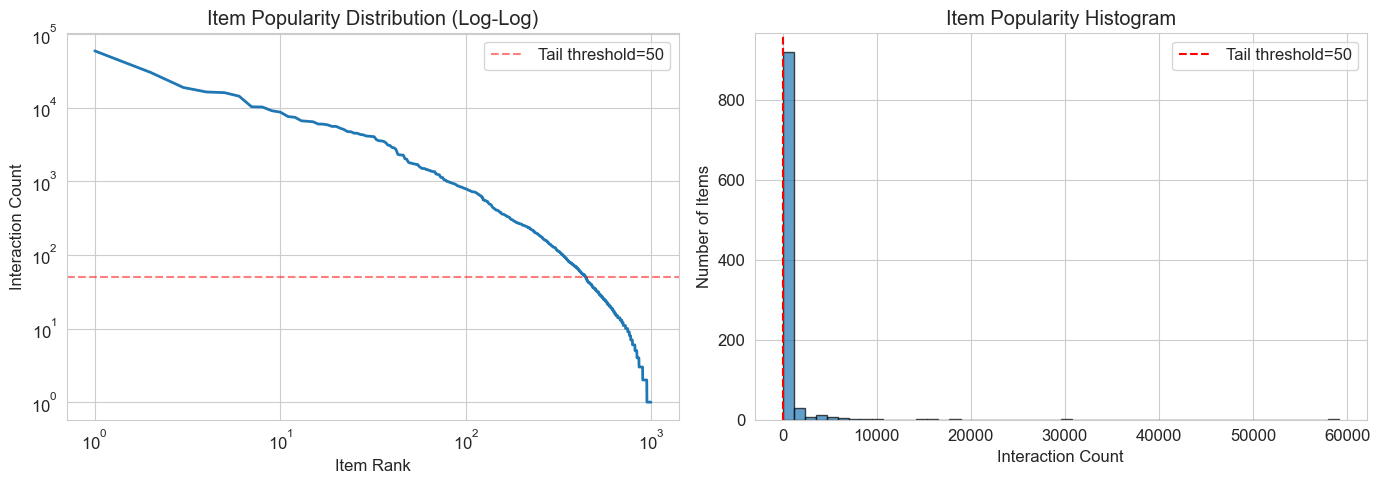


=== Long-Tail Analysis ===
Total items with interactions: 994
Tail items (< 50 interactions): 550 (55.3%)
Head items (≥ 50 interactions): 444 (44.7%)
Tail interactions: 7,799 (1.6%)
Head interactions: 492,201 (98.4%)

→ SANS opportunity: 550 tail items to improve recall for


In [25]:
# Item popularity distribution
item_counts = Counter()
for uid, seq in user_sequences.items():
    for e in seq:
        item_counts[e['item_id']] += 1

popularities = list(item_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Log-log plot
sorted_pops = sorted(popularities, reverse=True)
ax1.loglog(range(1, len(sorted_pops)+1), sorted_pops, linewidth=2)
ax1.set_xlabel('Item Rank')
ax1.set_ylabel('Interaction Count')
ax1.set_title('Item Popularity Distribution (Log-Log)')
ax1.axhline(50, color='red', linestyle='--', alpha=0.5, label='Tail threshold=50')
ax1.legend()

# Histogram
ax2.hist(popularities, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(50, color='red', linestyle='--', label='Tail threshold=50')
ax2.set_xlabel('Interaction Count')
ax2.set_ylabel('Number of Items')
ax2.set_title('Item Popularity Histogram')
ax2.legend()

plt.tight_layout()
plt.show()

# Tail statistics
tail_items = [iid for iid, cnt in item_counts.items() if cnt < 50]
head_items = [iid for iid, cnt in item_counts.items() if cnt >= 50]
print(f'\n=== Long-Tail Analysis ===')
print(f'Total items with interactions: {len(item_counts):,}')
print(f'Tail items (< 50 interactions): {len(tail_items):,} ({len(tail_items)/len(item_counts)*100:.1f}%)')
print(f'Head items (≥ 50 interactions): {len(head_items):,} ({len(head_items)/len(item_counts)*100:.1f}%)')
print(f'Tail interactions: {sum(item_counts[i] for i in tail_items):,} ({sum(item_counts[i] for i in tail_items)/sum(popularities)*100:.1f}%)')
print(f'Head interactions: {sum(item_counts[i] for i in head_items):,} ({sum(item_counts[i] for i in head_items)/sum(popularities)*100:.1f}%)')
print(f'\n→ SANS opportunity: {len(tail_items):,} tail items to improve recall for')

In [26]:
# Top 20 most popular games
top_games = item_counts.most_common(20)
item_id_to_title = {}
for g in games:
    if 'id' in g:
        item_id_to_title[str(g['id'])] = g.get('title', g.get('app_name', ''))

print('Top 20 Most Popular Games:')
for i, (gid, cnt) in enumerate(top_games):
    title = item_id_to_title.get(gid, 'Unknown')
    print(f'  {i+1:2d}. [{gid}] {title[:60]:60s} — {cnt:5d} interactions')

Top 20 Most Popular Games:
   1. [271590] Grand Theft Auto V                                           — 59107 interactions
   2. [291550] Brawlhalla                                                   — 30117 interactions
   3. [227940] Heroes &amp; Generals                                        — 18818 interactions
   4. [225080] Brothers - A Tale of Two Sons                                — 16350 interactions
   5. [200710] Torchlight II                                                — 16009 interactions
   6. [48700] Mount &amp; Blade: Warband                                   — 14328 interactions
   7. [337000] Deus Ex: Mankind Divided                                     — 10287 interactions
   8. [307780] Mortal Kombat X                                              — 10214 interactions
   9. [35140] Batman: Arkham Asylum Game of the Year Edition               —  9098 interactions
  10. [233720] Surgeon Simulator                                            —  8703 interactions
  11.

## 6. Genre Diversity & Entropy (→ RecAug)

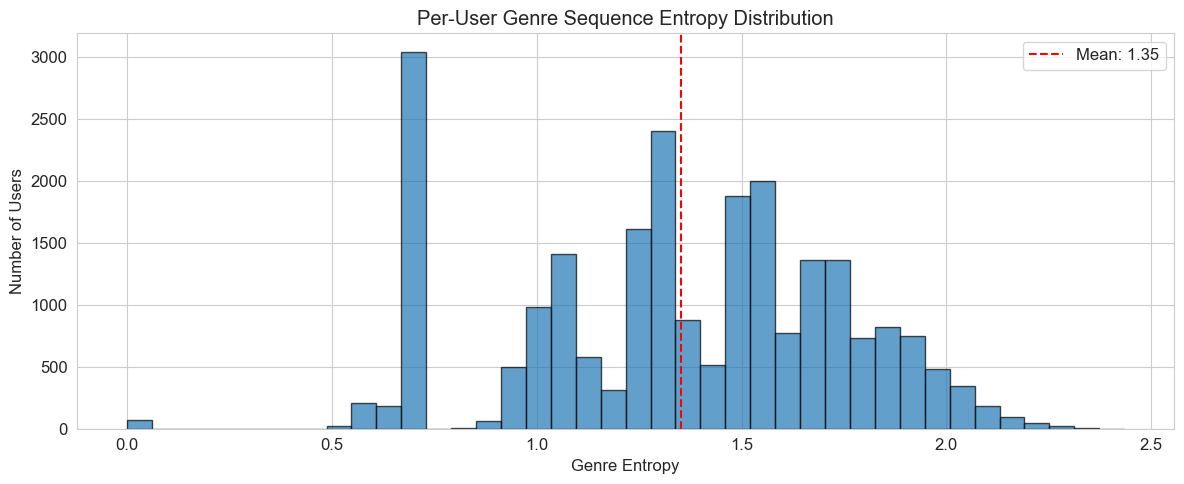


=== RecAug Redundancy Analysis ===
Low entropy (high redundancy):  5908 users → aggressive truncation
High entropy (low redundancy): 5856 users → light augmentation


In [14]:
# Genre diversity per user sequence
item_id_to_genres = {}
for g in games:
    if 'id' in g:
        item_id_to_genres[str(g['id'])] = g.get('genres', g.get('tags', []))

def seq_genre_entropy(seq):
    """Compute genre entropy for a user sequence."""
    all_g = []
    for e in seq:
        genres = item_id_to_genres.get(e['item_id'], [])
        all_g.extend(genres)
    if not all_g:
        return 0.0
    cnt = Counter(all_g)
    total = sum(cnt.values())
    probs = [c/total for c in cnt.values()]
    return -sum(p * np.log(p + 1e-10) for p in probs)

entropies = []
for uid, seq in user_sequences.items():
    if len(seq) >= 3:
        entropies.append(seq_genre_entropy(seq))

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(entropies, bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('Genre Entropy')
ax.set_ylabel('Number of Users')
ax.set_title('Per-User Genre Sequence Entropy Distribution')
ax.axvline(np.mean(entropies), color='red', linestyle='--',
           label=f'Mean: {np.mean(entropies):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

# Low entropy = redundant sequences → aggressive RecAug truncation
# High entropy = diverse sequences → light RecAug, keep all intent info
low_entropy = sum(1 for e in entropies if e < np.percentile(entropies, 25))
high_entropy = sum(1 for e in entropies if e > np.percentile(entropies, 75))
print(f'\n=== RecAug Redundancy Analysis ===')
print(f'Low entropy (high redundancy):  {low_entropy} users → aggressive truncation')
print(f'High entropy (low redundancy): {high_entropy} users → light augmentation')

## 7. Temporal Analysis (→ Session Boundaries)

Users with timestamped sequences: 78837


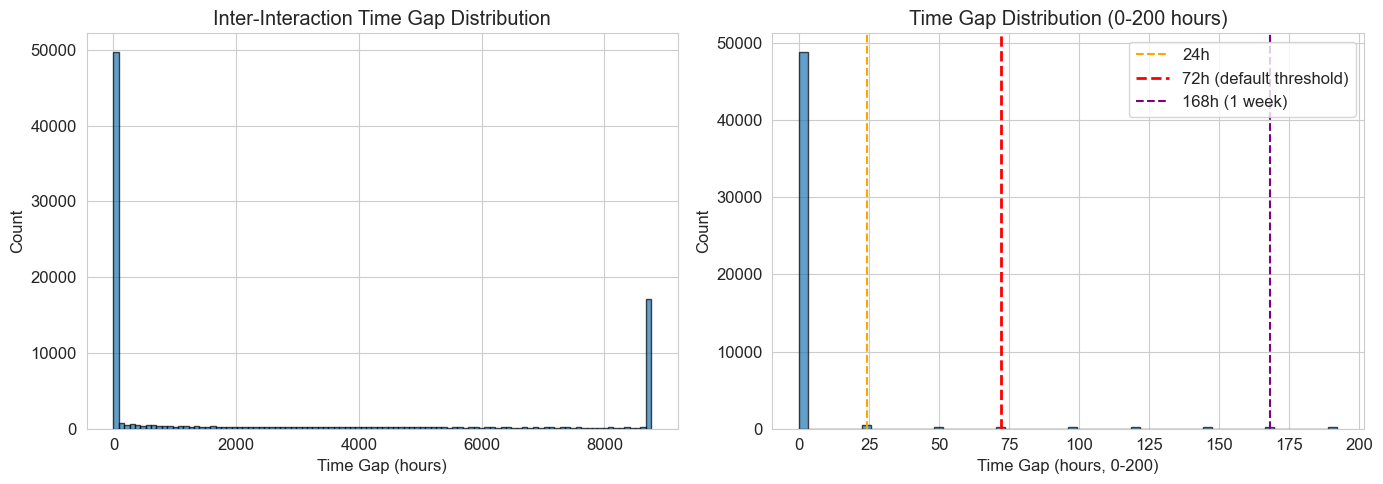


=== Session Boundary Analysis ===
Gaps < 24h (same session):      54.6%
Gaps < 72h (default threshold):  55.3%
Gaps ≥ 72h (new session):        44.7%
Avg potential session boundaries per user: 1.1


In [27]:
# Parse dates and compute time gaps
from utils.steam_utils import timestamp_to_unix

time_gaps_hours = []
valid_users = 0
for uid, seq in user_sequences.items():
    if len(seq) < 2:
        continue
    timestamps = []
    for e in seq:
        ts = timestamp_to_unix(e['date'])
        if ts:
            timestamps.append(ts)
    if len(timestamps) < 2:
        continue
    valid_users += 1
    for i in range(1, len(timestamps)):
        gap = (timestamps[i] - timestamps[i-1]) / 3600  # hours
        if gap >= 0:  # ignore negative (bad data)
            time_gaps_hours.append(min(gap, 8760))  # cap at 1 year

print(f'Users with timestamped sequences: {valid_users}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
ax1.hist(time_gaps_hours, bins=100, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Time Gap (hours)')
ax1.set_ylabel('Count')
ax1.set_title('Inter-Interaction Time Gap Distribution')

# Zoomed: 0-200 hours
short_gaps = [g for g in time_gaps_hours if g <= 200]
ax2.hist(short_gaps, bins=60, edgecolor='black', alpha=0.7)
ax2.axvline(24, color='orange', linestyle='--', label='24h')
ax2.axvline(72, color='red', linestyle='--', linewidth=2, label='72h (default threshold)')
ax2.axvline(168, color='purple', linestyle='--', label='168h (1 week)')
ax2.set_xlabel('Time Gap (hours, 0-200)')
ax2.set_ylabel('Count')
ax2.set_title('Time Gap Distribution (0-200 hours)')
ax2.legend()

plt.tight_layout()
plt.show()

# Session boundary statistics
lt_24h = sum(1 for g in time_gaps_hours if g < 24) / len(time_gaps_hours) * 100
lt_72h = sum(1 for g in time_gaps_hours if g < 72) / len(time_gaps_hours) * 100
gt_72h = sum(1 for g in time_gaps_hours if g >= 72) / len(time_gaps_hours) * 100
print(f'\n=== Session Boundary Analysis ===')
print(f'Gaps < 24h (same session):      {lt_24h:.1f}%')
print(f'Gaps < 72h (default threshold):  {lt_72h:.1f}%')
print(f'Gaps ≥ 72h (new session):        {gt_72h:.1f}%')
mean_sessions = len(time_gaps_hours) / valid_users
print(f'Avg potential session boundaries per user: {mean_sessions:.1f}')

## 8. Review Text Quality (→ LLM Operations)

Records with text reviews: 485,060/500,000 (97.0%)


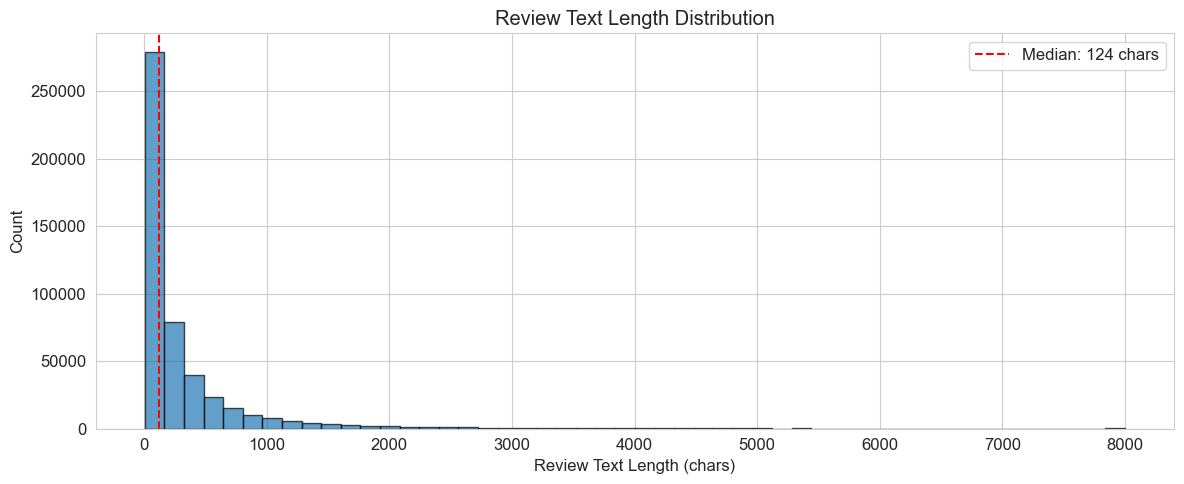

Min text length: 6
Max text length: 8000
Mean text length: 332
Median text length: 124

=== Sample Review Texts ===

  [1] User: Chaos Syren
      Game: 725280
      Hours: 0.1h
      Review: This would not be acceptable as an entertainment even back in the day when these graphics were all there was to be had. No effort has been made to bring the player into any story or even entertain.

  [2] User: ₮ʜᴇ Wᴀʀᴛᴏɴ
      Game: 328100
      Hours: 51.1h
      Review: looks like a facebook game

  [3] User: hello?<
      Game: 328100
      Hours: 14.6h
      Review: Better than Minecraft

  [4] User: Cyderine916
      Game: 35140
      Hours: 5.0h
      Review: I love and idolized Batman and this game is Masterpiece for me.

  [5] User: DarklyThinking
      Game: 35140
      Hours: 16.6h
      Review: Still worth playing in 2018.
Probably my favorite batman game overall.
It lacks the open world aspect of its sequels but makes up for it with a condensed and tense story.
Getting 100% of the tro

In [28]:
# Analyze review text quality
text_lengths = []
has_text = 0
non_english = 0

for r in reviews:
    text = r.get('text', '')
    if text and len(text) > 5:
        has_text += 1
        text_lengths.append(len(text))

print(f'Records with text reviews: {has_text:,}/{len(reviews):,} ({has_text/len(reviews)*100:.1f}%)')

if text_lengths:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(text_lengths, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.median(text_lengths), color='red', linestyle='--',
               label=f'Median: {np.median(text_lengths):.0f} chars')
    ax.set_xlabel('Review Text Length (chars)')
    ax.set_ylabel('Count')
    ax.set_title('Review Text Length Distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f'Min text length: {min(text_lengths)}')
    print(f'Max text length: {max(text_lengths)}')
    print(f'Mean text length: {np.mean(text_lengths):.0f}')
    print(f'Median text length: {np.median(text_lengths):.0f}')

# Sample review texts
print('\n=== Sample Review Texts ===')
for i, r in enumerate(reviews[:5]):
    text = r.get('text', 'N/A')[:200]
    print(f'\n  [{i+1}] User: {r.get("username", "?")}')
    print(f'      Game: {r.get("product_id", "?")}')
    print(f'      Hours: {r.get("hours", 0)}h')
    print(f'      Review: {text}...' if len(r.get('text','')) > 200 else f'      Review: {text}')

## 9. K-Core Filtering Simulation

In [29]:
# Simulate k-core filtering effects
from preprocess import k_core_filter

print('=== K-Core Filtering Impact ===')
for k in [3, 5, 10, 20]:
    # Make copies to avoid mutation
    us_copy = {uid: list(seq) for uid, seq in user_sequences.items()}
    cat_copy = {iid: dict(info) for iid, info in item_id_to_genres.items()}
    
    filtered_users, filtered_cat = k_core_filter(us_copy, {}, k=k)
    n_users = len(filtered_users)
    n_items = len(filtered_cat) if filtered_cat else len(set(
        e['item_id'] for seq in filtered_users.values() for e in seq
    ))
    
    retention_u = n_users / len(user_sequences) * 100
    print(f'  k={k:2d}: {n_users:6d} users ({retention_u:.1f}%), {n_items:5d} items')

=== K-Core Filtering Impact ===


ValueError: dictionary update sequence element #0 has length 6; 2 is required

## 10. Summary & Method Implications

In [ ]:
print('=' * 60)
print('KEY FINDINGS & METHOD IMPLICATIONS')
print('=' * 60)

print(f'''
Dataset Scale:
  Games: {len(games):,}  |  Reviews (sampled): {len(reviews):,}  |  Total: ~7.8M
  Users: {len(user_sequences):,}  |  Avg seq len: {np.mean(seq_lengths):.1f}

RecCL Feasibility:
  Short seq (≤10): {short_pct:.1f}%  → Stage 1: easy CF patterns
  Medium seq (11-30): {medium_pct:.1f}%  → Stage 2: transition patterns
  Long seq (>30): {long_pct:.1f}%  → Stage 3: semantic reasoning
  Sequence length variance is high → 3D curriculum is well-motivated

SANS Opportunity:
  Tail items: {len(tail_items):,} ({len(tail_items)/len(item_counts)*100:.1f}%)
  These are hard to recommend → semantic negative sampling can help
  Steam's rich genre/tag text makes LLM hard-negatives feasible

RecAug Applicability:
  Low-entropy users: great for intent-preserving truncation
  Session gaps ≥72h: {gt_72h:.1f}% → plenty of session boundaries for permutation
  Game text quality: {has_text/len(reviews)*100:.1f}% reviews have text → LLM intent analysis viable

Data Readiness:
  ID alignment: {len(aligned):,}/{len(review_pids):,} ({len(aligned)/max(len(review_pids),1)*100:.1f}%)
  → {'✓ Good' if len(aligned)/max(len(review_pids),1) > 0.7 else '⚠ Need to handle {len(review_only):,} review-only items'}
''')